In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import folium
from branca.colormap import linear
import geopandas as gpd
import json
from shapely.geometry import shape
import geopandas as gpd
warnings.filterwarnings("ignore")
from DadosAbertosBrasil import ibge

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df_oncologia = pd.read_csv("./dados/dados_oncologicos_filtrados.csv")
df_oncologia = df_oncologia[[ 'ANO_DIAGN', 'ANO_TRATAM','UF_RESID', 'MUN_RESID', 'UF_DIAGN','UF_TRATAM', 'MUN_TRATAM', 'TRATAMENTO', 'IDADE','ESTADIAM','TEMPO_TRAT','DIAG_DETH', 'DT_DIAG', 'DT_TRAT', 'DT_NASC']]
df_oncologia = df_oncologia.rename(columns={
    "ANO_DIAGN": "ano_diagnostico", 
    "ANO_TRATAM": "ano_tratamento", 
    "UF_RESID": "uf_residencia", 
    "MUN_RESID": "codigo_municipio_residencia", 
    "UF_DIAGN": "uf_diagnostico",
    "UF_TRATAM": "uf_tratamento", 
    "MUN_TRATAM": "codigo_municipio_tratamento", 
    "ESTADIAM": "estadiamento", 
    "TEMPO_TRAT": "tempo_tratamento",
    "DIAG_DETH": "diagnostico",
    "DT_DIAG": "data_diagnostico",
    "DT_TRAT": "data_tratamento",
    "DT_NASC": "data_nascimento",
})
#df_oncologia = df_oncologia[df_oncologia['ano_tratamento'] < 2020]
df_oncologia['data_diagnostico'] = pd.to_datetime(df_oncologia['data_diagnostico'])
df_oncologia['data_tratamento'] = pd.to_datetime(df_oncologia['data_tratamento'])  
df_oncologia['codigo_municipio_residencia'] = df_oncologia['codigo_municipio_residencia'].astype(str)
df_oncologia['codigo_municipio_residencia'] = df_oncologia['codigo_municipio_residencia'].str.slice(0, 6)
len(df_oncologia)

159353

In [3]:
df_oncologia['data_diagnostico'].max()

Timestamp('2024-12-31 00:00:00')

In [4]:
df_oncologia['ano_tratamento'].unique()

array([2021.,   nan, 2024., 2013., 2023., 2014., 2020., 2018., 2019.,
       2022., 2015., 2017., 2016.])

In [5]:
df_regiao = pd.read_csv("./dados/ibge/municipios_regioes.csv")
df_regiao = df_regiao[['codigo_municipio_ibge_novo', 'nome_municipio', 'nome_uf', 'uf', 'regiao', 'cod_uf']]
df_regiao = df_regiao.rename(columns={
    "codigo_municipio_ibge_novo": "codigo_municipio_residencia"
})
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].astype(str)
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].str.slice(0, 6)

In [6]:
dados_completos = pd.merge(df_oncologia, df_regiao, on='codigo_municipio_residencia', how='inner')
len(dados_completos)

131243

### % Tratamentos iniciados após 60 dias desde o diagnóstico

In [83]:
dados_completos_cp = dados_completos.copy()
dados_completos_cp = dados_completos_cp.query("tempo_tratamento != 99999")
dados_completos_cp = dados_completos_cp[dados_completos_cp['tempo_tratamento'].notna()]
dados_completos_cp = dados_completos_cp[dados_completos_cp['ano_tratamento'] >= 2024]

In [80]:
casos_acima_60 = dados_completos_cp[dados_completos_cp["tempo_tratamento"] > 60].groupby("cod_uf").size()
total_casos = dados_completos_cp.groupby("cod_uf").size()
percentual = (casos_acima_60 / total_casos).fillna(0) * 100
percentual = percentual.reset_index(name="percentual_acima_60_dias").round({"percentual_acima_60_dias": 4})
percentual.to_clipboard(decimal=",")


In [81]:
geojson_path = ibge.malha(
    nivel = 'paises',
    localidade = 'BR',
    divisoes = 'municipio',
    formato = 'geojson'
)

In [82]:
geojson_path = ibge.malha(
    nivel = 'paises',
    localidade = 'BR',
    divisoes = 'uf',
    formato = 'geojson'
)
mapa = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles=None)
colormap = linear.YlOrRd_09.scale(0, 100)  # Define a escala fixa de 0 a 100
colormap.caption = 'Percentual de casos com tratamento após 60 dias (%)'
colormap.caption = 'Tempo médio de tratamento (dias)'
folium.Choropleth(
    geo_data=geojson_path,
    data=percentual,
    columns=["cod_uf", "percentual_acima_60_dias"],
    key_on="feature.properties.codarea",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Tempo médio de tratamento (dias)",
    nan_fill_color="white",
    nan_fill_opacity=0.3
).add_to(mapa)

# Gera o HTML da legenda com tamanho de fonte maior
colormap_html = colormap._repr_html_().replace(
    '<div style="position: relative;',
    '<div style="position: relative; font-size: 16px;'  # Aumenta o tamanho da fonte
)

# Adiciona a legenda modificada ao mapa
mapa.get_root().html.add_child(folium.Element(colormap_html))
if isinstance(geojson_path, dict):
    gdf = gpd.GeoDataFrame.from_features(geojson_path["features"])
else:
    gdf = gpd.read_file(geojson_path)  

gdf["codarea"] = gdf["codarea"].astype(int)

for _, row in gdf.iterrows():
    estado_codigo = row["codarea"]
    centroide = row.geometry.centroid  
    tempo_tratamento = percentual.loc[percentual["cod_uf"] == estado_codigo, "percentual_acima_60_dias"]
    if not tempo_tratamento.empty:
        valor = f"{round(tempo_tratamento.values[0], 1)}%" 
        folium.Marker(
            location=[centroide.y, centroide.x], 
            icon=folium.DivIcon(html=f"""
                <div style="
                    font-size: 12px; 
                    font-weight: bold; 
                    color: black; 
                    background: rgba(255,255,255,0.85);
                    padding: 4px 6px;
                    border-radius: 5px;
                    text-align: center;
                    display: inline-block;
                    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
                    border: 1px solid rgba(0,0,0,0.2);
                ">
                    {valor}
                </div>""")
        ).add_to(mapa)
mapa.get_root().html.add_child(folium.Element("""
    <style>
        html, body {
            background-color: white !important;
            height: 100%;
            margin: 0;
        }
        .folium-map { background: white; }
        #map { height: 100%; }
    </style>
"""))
mapa.save("teste.html")


#### Tempo em faixas

In [11]:
df_oncologia = pd.read_csv("./dados_oncologicos_filtrados.csv")
df_oncologia = df_oncologia[[ 'ANO_DIAGN', 'ANO_TRATAM','UF_RESID', 'MUN_RESID', 'UF_DIAGN','UF_TRATAM', 'MUN_TRATAM', 'TRATAMENTO', 'IDADE','ESTADIAM','TEMPO_TRAT','DIAG_DETH', 'DT_DIAG', 'DT_TRAT', 'DT_NASC']]
df_oncologia = df_oncologia.rename(columns={
    "ANO_DIAGN": "ano_diagnostico", 
    "ANO_TRATAM": "ano_tratamento", 
    "UF_RESID": "uf_residencia", 
    "MUN_RESID": "codigo_municipio_residencia", 
    "UF_DIAGN": "uf_diagnostico",
    "UF_TRATAM": "uf_tratamento", 
    "MUN_TRATAM": "codigo_municipio_tratamento", 
    "ESTADIAM": "estadiamento", 
    "TEMPO_TRAT": "tempo_tratamento",
    "DIAG_DETH": "diagnostico",
    "DT_DIAG": "data_diagnostico",
    "DT_TRAT": "data_tratamento",
    "DT_NASC": "data_nascimento",
})

df_oncologia = df_oncologia[df_oncologia['ano_diagnostico'] <= 2025]
df_oncologia = df_oncologia[df_oncologia['ano_diagnostico'] > 2016]

df_oncologia['data_diagnostico'] = pd.to_datetime(df_oncologia['data_diagnostico'])
df_oncologia['data_tratamento'] = pd.to_datetime(df_oncologia['data_tratamento'])  
df_oncologia['codigo_municipio_residencia'] = df_oncologia['codigo_municipio_residencia'].astype(str)
df_oncologia['codigo_municipio_residencia'] = df_oncologia['codigo_municipio_residencia'].str.slice(0, 6)
len(df_oncologia)

153159

In [12]:
dados_tempo = df_oncologia.copy()
dados_tempo["faixa_tempo_tratamento"] = pd.cut(
    dados_tempo["tempo_tratamento"],
    bins=[-float("inf"), 30, 60, float("inf")],
    labels=["Até 30 dias", "31 a 60 dias", "Mais de 60 dias"]
)

dados_tempo = dados_tempo.dropna(subset=['ano_diagnostico', 'faixa_tempo_tratamento'])
dados_tempo = dados_tempo.query("tempo_tratamento != 99999")

In [88]:
df_grouped_sorted.to_clipboard(decimal=",")

In [ ]:
dados_tempo.groupy([''])

,ano_diagnostico,ano_tratamento,uf_residencia,codigo_municipio_residencia,uf_diagnostico,uf_tratamento,codigo_municipio_tratamento,TRATAMENTO,IDADE,estadiamento,tempo_tratamento,diagnostico,data_diagnostico,data_tratamento,data_nascimento,faixa_tempo_tratamento
6200,2017,2017.0,22,221100,22,22.0,221100.0,1,39,5.0,57.0,C53,2017-06-20,2017-08-16,1977-10-18,31 a 60 dias
6201,2017,2017.0,31,313670,31,31.0,313670.0,1,54,5.0,63.0,C53,2017-03-29,2017-05-31,1962-07-28,Mais de 60 dias
6208,2017,2018.0,32,320400,32,32.0,320530.0,1,47,5.0,246.0,C53,2017-10-18,2018-06-21,1970-03-27,Mais de 60 dias
6209,2017,2020.0,15,150200,15,15.0,150140.0,2,41,2.0,1064.0,C53,2017-07-31,2020-06-29,1975-12-19,Mais de 60 dias
6210,2017,2017.0,51,510340,51,51.0,510340.0,1,33,5.0,5.0,C53,2017-10-27,2017-11-01,1984-02-15,Até 30 dias
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155895,2024,2024.0,31,311860,31,31.0,310620.0,3,36,3.0,68.0,C53,2024-04-12,2024-06-19,1987-06-22,Mais de 60 dias
155896,2024,2024.0,35,354100,35,35.0,354850.0,2,47,3.0,111.0,C53,2024-06-07,2024-09-26,1977-04-20,Mais de 60 dias
155897,2024,2024.0,52,522045,52,52.0,520870.0,2,45,2.0,43.0,C53,2024-07-31,2024-09-12,1979-01-30,31 a 60 dias
155900,2024,2024.0,42,420290,42,42.0,420240.0,3,45,2.0,63.0,C53,2024-07-10,2024-09-11,1978-11-20,Mais de 60 dias


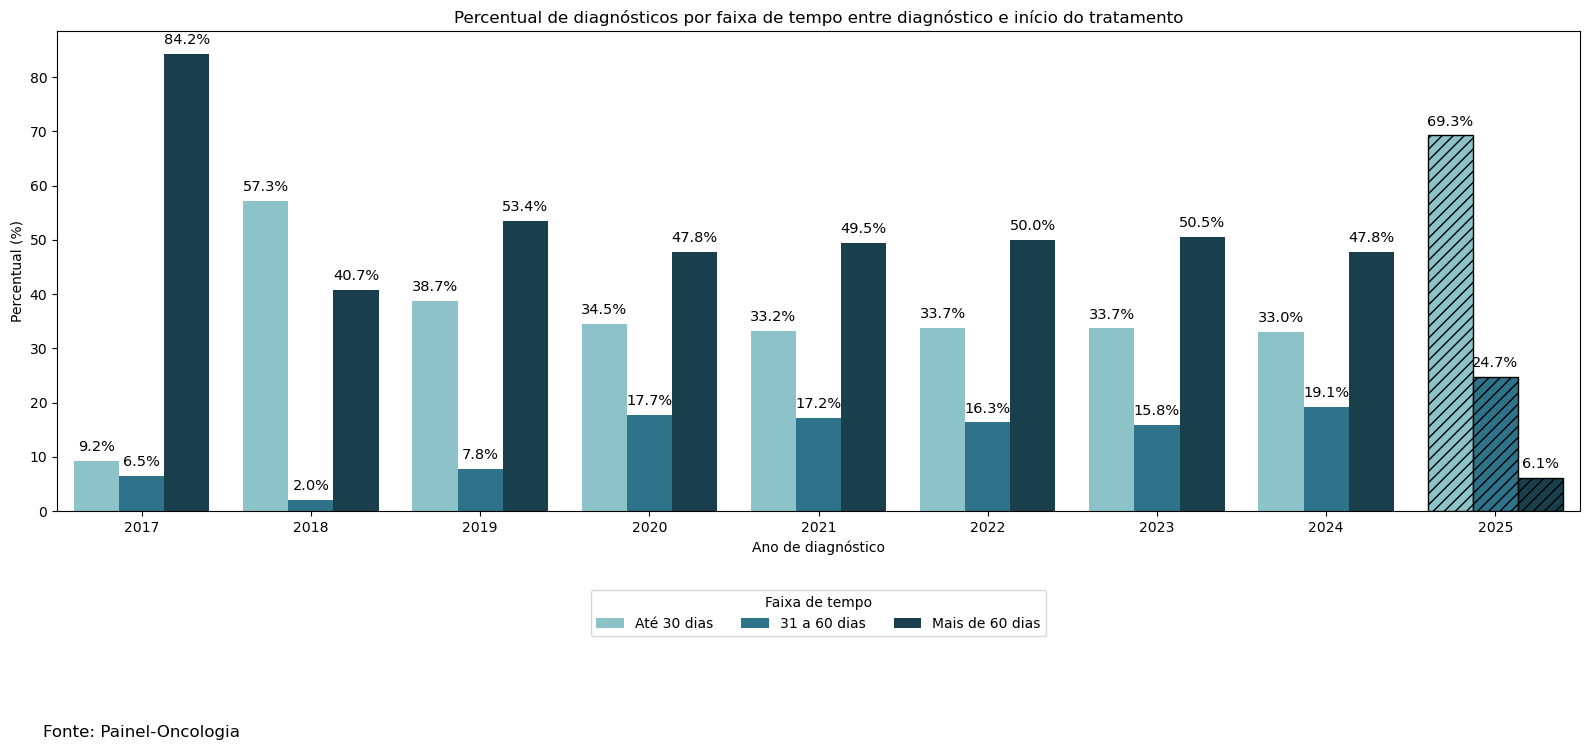

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_grouped = dados_tempo.groupby(['ano_diagnostico', 'faixa_tempo_tratamento']).size().reset_index(name='quantidade_diagnosticos')
df_grouped['percentual'] = df_grouped.groupby('ano_diagnostico')['quantidade_diagnosticos'].transform(lambda x: x / x.sum() * 100)
df_grouped_sorted = df_grouped.sort_values(['ano_diagnostico', 'faixa_tempo_tratamento']).reset_index(drop=True)

seq_blue = ["#81CBD3", "#1F7A99", "#114354"]
sns.set_palette(seq_blue)

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    x='ano_diagnostico',
    y='percentual',
    hue='faixa_tempo_tratamento',
    data=df_grouped_sorted,
    palette=seq_blue
)

xticks_labels = [tick.get_text() for tick in ax.get_xticklabels()]
xticks_positions = ax.get_xticks()

# Converter labels para int
anos = [int(label) for label in xticks_labels]
posicoes = xticks_positions

# Encontrar posição de 2025
pos_2025 = None
idx_2025 = None
for i, ano in enumerate(anos):
    if ano == 2025:
        pos_2025 = posicoes[i]
        idx_2025 = i
        break

# Calcular limites do grupo 2025
if pos_2025 is not None:
    # Limite esquerdo: média entre posição de 2025 e anterior (ou subtraia 0.5 se for primeiro)
    if idx_2025 > 0:
        left_limit = (posicoes[idx_2025] + posicoes[idx_2025 -1]) / 2
    else:
        left_limit = posicoes[idx_2025] - 0.5

    # Limite direito: média entre posição de 2025 e próxima (ou some 0.5 se for último)
    if idx_2025 < len(posicoes) -1:
        right_limit = (posicoes[idx_2025] + posicoes[idx_2025 +1]) / 2
    else:
        right_limit = posicoes[idx_2025] + 0.5

    # Aplicar hachura para barras cujas posições centrais estejam entre left_limit e right_limit
    for bar in ax.patches:
        x_bar = bar.get_x() + bar.get_width() / 2
        if left_limit <= x_bar <= right_limit:
            bar.set_hatch('///')
            bar.set_edgecolor('black')
            bar.set_linewidth(1)

# Adicionar rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=5, fontsize=10.5, label_type='edge')

plt.legend(
    title='Faixa de tempo',
    title_fontsize=10,
    fontsize=10,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)

plt.xlabel('Ano de diagnóstico')
plt.ylabel('Percentual (%)')
plt.title('Percentual de diagnósticos por faixa de tempo entre diagnóstico e início do tratamento')

plt.figtext(0.03, -0.06, "Fonte: Painel-Oncologia", ha='left', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### Em qual estagio a doenca é mais diagnosticada?

In [61]:
df_oncologia = pd.read_csv("./dados_oncologicos_filtrados.csv")
df_oncologia = df_oncologia[[ 'ANO_DIAGN', 'ANO_TRATAM','UF_RESID', 'MUN_RESID', 'UF_DIAGN','UF_TRATAM', 'MUN_TRATAM', 'TRATAMENTO', 'IDADE','ESTADIAM','TEMPO_TRAT','DIAG_DETH', 'DT_DIAG', 'DT_TRAT', 'DT_NASC']]
df_oncologia = df_oncologia.rename(columns={
    "ANO_DIAGN": "ano_diagnostico", 
    "ANO_TRATAM": "ano_tratamento", 
    "UF_RESID": "uf_residencia", 
    "MUN_RESID": "codigo_municipio_residencia", 
    "UF_DIAGN": "uf_diagnostico",
    "UF_TRATAM": "uf_tratamento", 
    "MUN_TRATAM": "codigo_municipio_tratamento", 
    "ESTADIAM": "estadiamento", 
    "TEMPO_TRAT": "tempo_tratamento",
    "DIAG_DETH": "diagnostico",
    "DT_DIAG": "data_diagnostico",
    "DT_TRAT": "data_tratamento",
    "DT_NASC": "data_nascimento",
})
#df_oncologia = df_oncologia[df_oncologia['ano_diagnostico'] == 2024]

df_oncologia['data_diagnostico'] = pd.to_datetime(df_oncologia['data_diagnostico'])
df_oncologia['data_tratamento'] = pd.to_datetime(df_oncologia['data_tratamento'])  
df_oncologia['codigo_municipio_residencia'] = df_oncologia['codigo_municipio_residencia'].astype(str)
df_oncologia['codigo_municipio_residencia'] = df_oncologia['codigo_municipio_residencia'].str.slice(0, 6)

In [62]:
df_agrupado = df_oncologia.groupby(['ano_diagnostico','estadiamento']).size().reset_index(name='quantidade_de_casos')
df_agrupado = df_agrupado.query("estadiamento != 5")
df_agrupado = df_agrupado.query("estadiamento != 9.0")
total_por_ano = df_agrupado.groupby('ano_diagnostico')['quantidade_de_casos'].transform('sum')
df_agrupado['proporcao_percentual'] = (df_agrupado['quantidade_de_casos'] / total_por_ano) * 100

In [89]:
df_agrupado.to_clipboard(decimal=",")

<Figure size 1600x800 with 0 Axes>

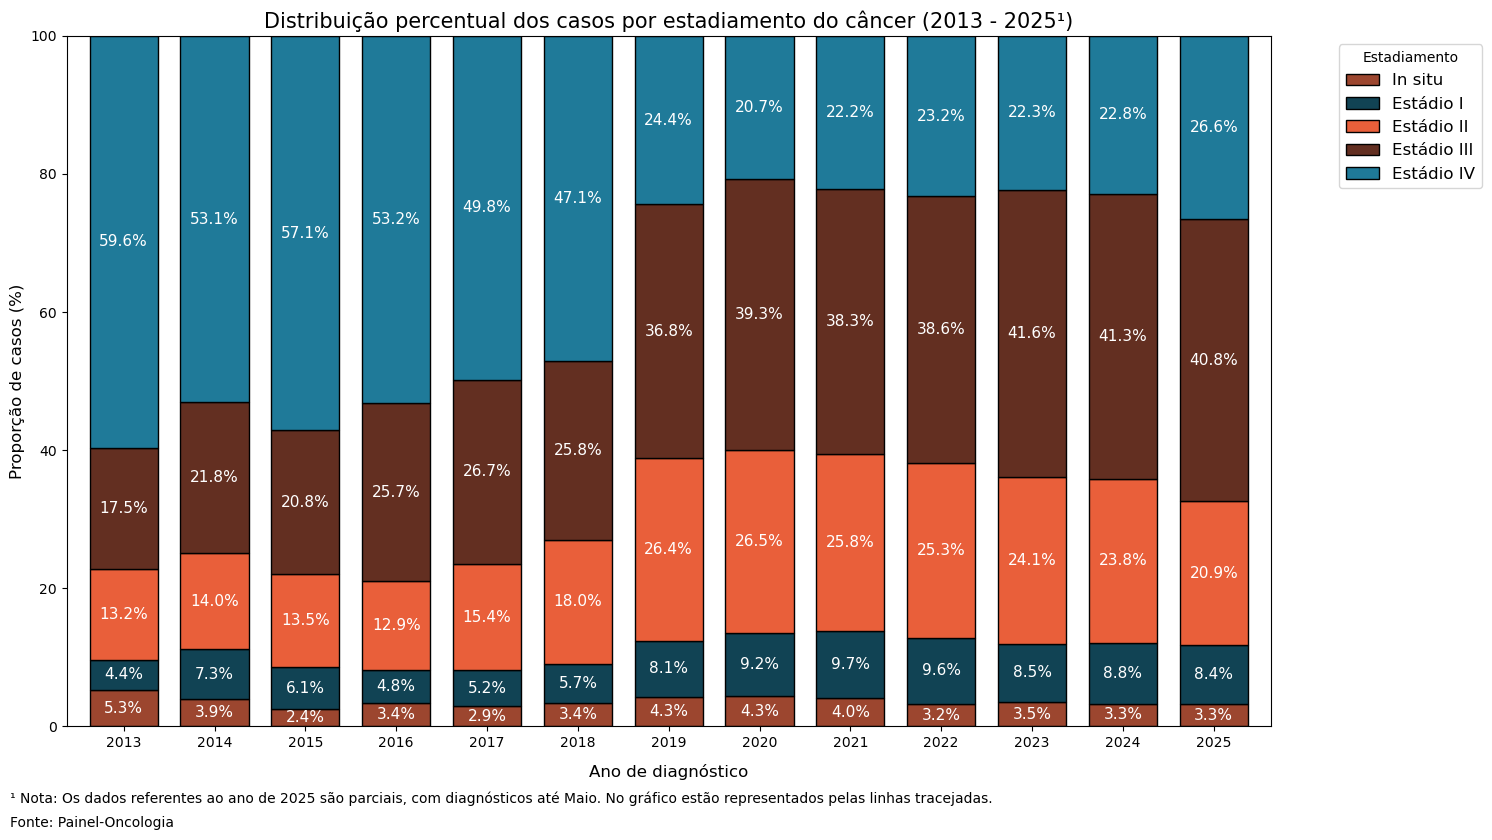

In [65]:
df_pivot = df_agrupado.pivot(index='ano_diagnostico', columns='estadiamento', values='proporcao_percentual')
legendas_personalizadas = {
    0: 'In situ',
    1: 'Estádio I',
    2: 'Estádio II',
    3: 'Estádio III',
    4: 'Estádio IV'
}
df_pivot.rename(columns=legendas_personalizadas, inplace=True)
ordem_estadiamento = ['In situ', 'Estádio I', 'Estádio II', 'Estádio III', 'Estádio IV']
df_pivot = df_pivot[ordem_estadiamento]
cat_colors = ["#114354", "#1F7A99", "#2EA6BC", "#81CBD3","#632F21", "#9C462F", "#E95F3A", "#EF8264"]
cat_colors = ["#9C462F", "#114354", "#E95F3A", "#632F21", "#1F7A99"]
plt.figure(figsize=(16, 8)) 
ax = df_pivot.plot(kind='bar', stacked=True, color=cat_colors, width=0.75, edgecolor='black', figsize=(15, 8))  
for i, patch in enumerate(ax.patches):
    height = patch.get_height()  
    width = patch.get_width() 
    x = patch.get_x() + width / 2 
    y = patch.get_y() + height / 2 
    ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=11, color='white')  
plt.title('Distribuição percentual dos casos por estadiamento do câncer (2013 - 2025¹)', fontsize=15) 
plt.xlabel('Ano de diagnóstico', fontsize=12, labelpad=10)
plt.ylabel('Proporção de casos (%)', fontsize=12)
plt.legend(title='Estadiamento', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(False)
plt.tight_layout()
plt.figtext(0.01, -0.01, "¹ Nota: Os dados referentes ao ano de 2025 são parciais, com diagnósticos até Maio. No gráfico estão representados pelas linhas tracejadas.", ha="left", fontsize=10)
plt.figtext(0.01, -0.04, "Fonte: Painel-Oncologia", ha="left", fontsize=10)

plt.show()

<Figure size 1600x800 with 0 Axes>

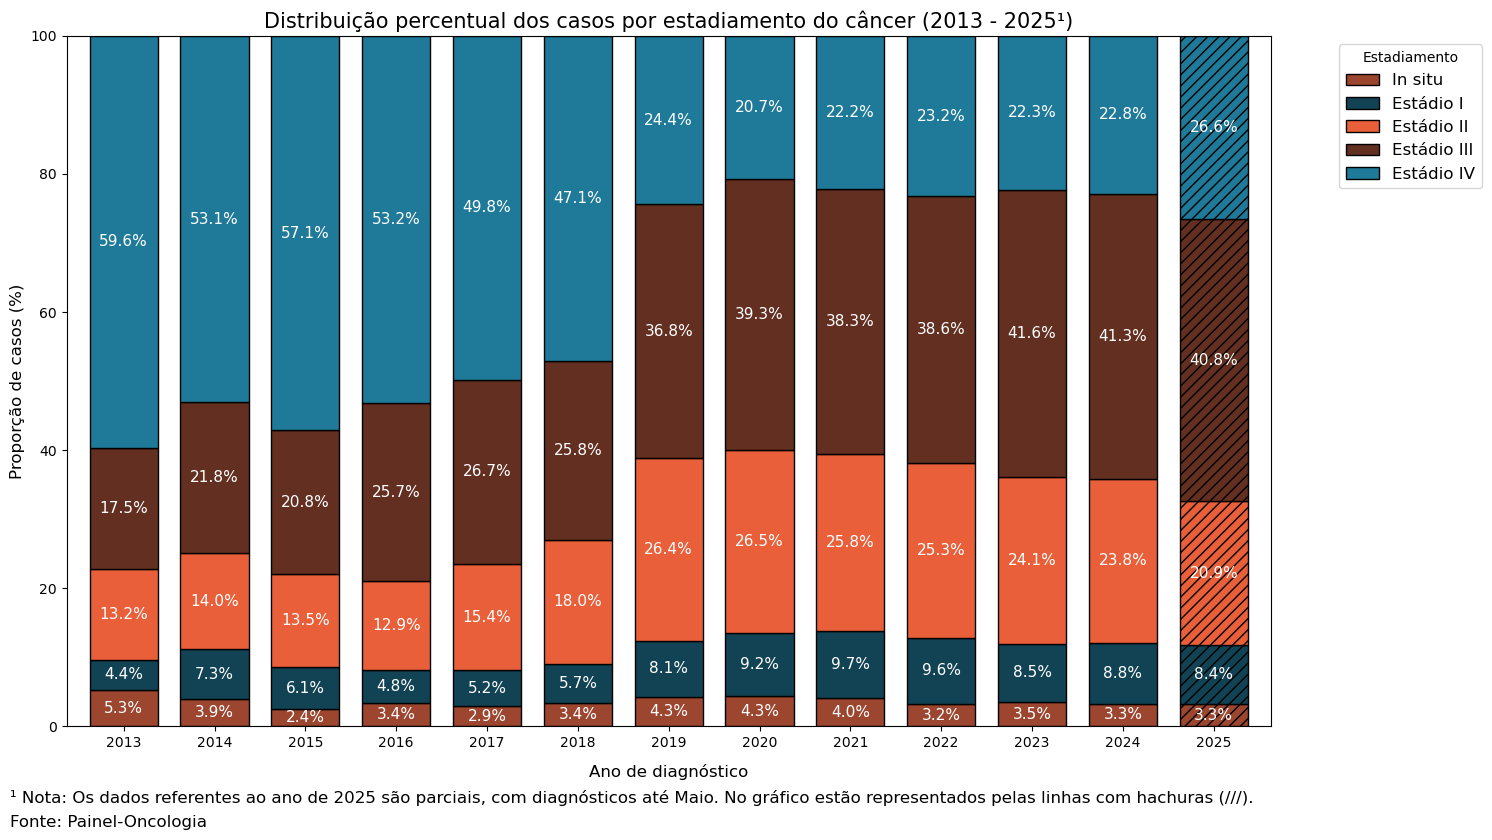

In [69]:
import matplotlib.pyplot as plt

# Criação do gráfico
plt.figure(figsize=(16, 8)) 
ax = df_pivot.plot(
    kind='bar', 
    stacked=True, 
    color=cat_colors, 
    width=0.75, 
    edgecolor='black', 
    figsize=(15, 8)
)

# Aplicar hachura apenas nas barras de 2025
anos = df_pivot.index.tolist()
n_estagios = df_pivot.shape[1]

for i, container in enumerate(ax.containers):
    for bar_idx, bar in enumerate(container):
        ano = anos[bar_idx]
        if ano == 2025:
            bar.set_hatch('///')

# Adicionar rótulos nas barras
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        width = bar.get_width()
        x = bar.get_x() + width / 2
        y = bar.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=11, color='white')

# Demais ajustes visuais
plt.title('Distribuição percentual dos casos por estadiamento do câncer (2013 - 2025¹)', fontsize=15) 
plt.xlabel('Ano de diagnóstico', fontsize=12, labelpad=10)
plt.ylabel('Proporção de casos (%)', fontsize=12)
plt.legend(title='Estadiamento', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(False)
plt.tight_layout()
plt.figtext(0.01, -0.01, "¹ Nota: Os dados referentes ao ano de 2025 são parciais, com diagnósticos até Maio. No gráfico estão representados pelas linhas com hachuras (///).", ha="left", fontsize=12)
plt.figtext(0.01, -0.04, "Fonte: Painel-Oncologia", ha="left", fontsize=12)

plt.show()
